In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def divisive_generic(x, score_function, max_cp=4, min_size=10):
    change_points = []

    def _split(start, end):
        if len(x[start:end]) < 2*min_size:
            return
        if len(change_points) >= max_cp:
            return

        ts, scores = score_function(x, start, end, min_size)

        if len(scores) == 0:
            return

        t_hat = ts[np.argmax(scores)]
        change_points.append(t_hat)

        # Recurse left and right
        _split(start, t_hat)
        _split(t_hat, end)

    _split(0, len(x))
    return sorted(change_points)

In [3]:
def score_meanvar(x, start, end, min_size):
    ts = np.arange(start+min_size, end-min_size)
    scores = []

    for t in ts:
        L = x[start:t]
        R = x[t:end]

        mean_diff = abs(np.mean(L) - np.mean(R))
        std_diff  = abs(np.std(L)  - np.std(R))

        # size weighting
        weight = len(L)*len(R)/(len(L)+len(R))

        scores.append(weight * (mean_diff + std_diff))

    return ts, np.array(scores)

In [4]:
def energy_distance(L, R):
    """Compute energy distance between two 1D arrays"""
    L, R = np.asarray(L), np.asarray(R)
    term1 = 2*np.mean(np.abs(L[:,None] - R[None,:]))
    term2 = np.mean(np.abs(L[:,None] - L[None,:]))
    term3 = np.mean(np.abs(R[:,None] - R[None,:]))
    return term1 - term2 - term3


def score_energy(x, start, end, min_size):
    ts = np.arange(start+min_size, end-min_size)
    scores = []

    for t in ts:
        L = x[start:t]
        R = x[t:end]

        weight = len(L)*len(R)/(len(L)+len(R))
        scores.append(weight * energy_distance(L, R))

    return ts, np.array(scores)

In [5]:
from scipy.stats import rankdata

def score_multirank(x, start, end, min_size):
    segment = x[start:end]
    ranks = rankdata(segment)

    ts = np.arange(start+min_size, end-min_size)
    scores = []

    for t in ts:
        split = t - start
        L = ranks[:split]
        R = ranks[split:]

        weight = len(L)*len(R)/(len(L)+len(R))
        scores.append(weight * abs(np.mean(L) - np.mean(R)))

    return ts, np.array(scores)

In [6]:
def rbf_kernel(x, y, sigma=1.0):
    return np.exp(-0.5 * ((x - y)/sigma)**2)

def kernel_score(L, R, sigma=1.0):
    # Compute mean embedding squared distance
    K_LL = np.mean(rbf_kernel(L[:,None], L[None,:], sigma))
    K_RR = np.mean(rbf_kernel(R[:,None], R[None,:], sigma))
    K_LR = np.mean(rbf_kernel(L[:,None], R[None,:], sigma))
    return K_LL + K_RR - 2*K_LR

def score_kernel(x, start, end, min_size, sigma=1.0):
    ts = np.arange(start+min_size, end-min_size)
    scores = []

    for t in ts:
        L = x[start:t]
        R = x[t:end]

        weight = len(L)*len(R)/(len(L)+len(R))
        scores.append(weight * kernel_score(L, R, sigma))

    return ts, np.array(scores)

def score_kernel_wrapper(x, start, end, min_size):
    return score_kernel(x, start, end, min_size, sigma=1.0)

In [14]:
np.random.seed(0)

n1, n2, n3 = 100, 100, 100

seg1 = np.random.normal(0, 1, n1)
seg2 = np.random.normal(3, 1, n2)
seg3 = np.random.normal(3, 9, n3) 
#seg3 = np.random.normal(3, 2, n3)

x = np.concatenate([seg1, seg2, seg3])

In [15]:
cp_meanvar  = divisive_generic(x, score_meanvar,  max_cp=4)
cp_energy   = divisive_generic(x, score_energy,   max_cp=4)
cp_rank     = divisive_generic(x, score_multirank,max_cp=4)
cp_kernel   = divisive_generic(x, score_kernel_wrapper, max_cp=4)

print("Mean+Var:", cp_meanvar)
print("Energy:", cp_energy)
print("Multirank:", cp_rank)
print("Kernel:", cp_kernel)

Mean+Var: [np.int64(19), np.int64(38), np.int64(81), np.int64(100)]
Energy: [np.int64(17), np.int64(38), np.int64(84), np.int64(100)]
Multirank: [np.int64(17), np.int64(32), np.int64(81), np.int64(100)]
Kernel: [np.int64(17), np.int64(38), np.int64(81), np.int64(100)]


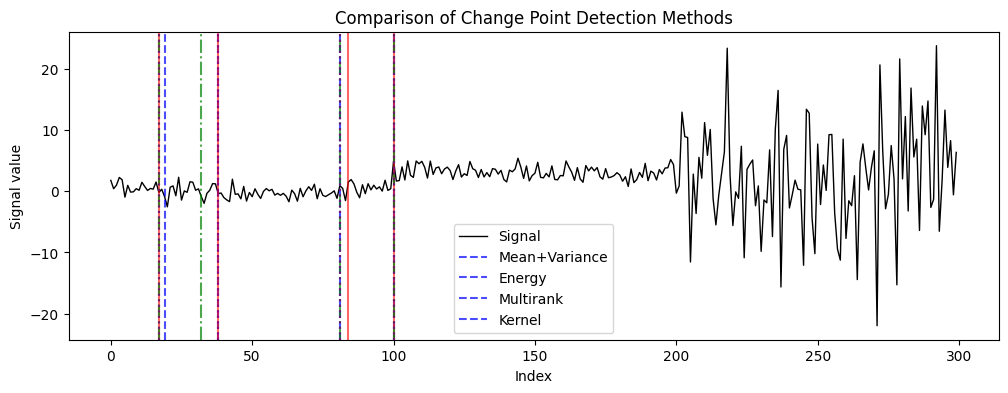

In [16]:
plt.figure(figsize=(12,4))
plt.plot(x, color='black', linewidth=1)

# Mean + Variance
for t in cp_meanvar:
    plt.axvline(t, color='blue', linestyle='--', alpha=0.7)

# Energy
for t in cp_energy:
    plt.axvline(t, color='red', linestyle='-', alpha=0.6)

# Multirank
for t in cp_rank:
    plt.axvline(t, color='green', linestyle='-.', alpha=0.7)

# Kernel
for t in cp_kernel:
    plt.axvline(t, color='purple', linestyle=':', alpha=0.8)

plt.title("Comparison of Change Point Detection Methods")
plt.xlabel("Index")
plt.ylabel("Signal value")

plt.legend([
    "Signal",
    "Mean+Variance",
    "Energy",
    "Multirank",
    "Kernel"
])

plt.show()

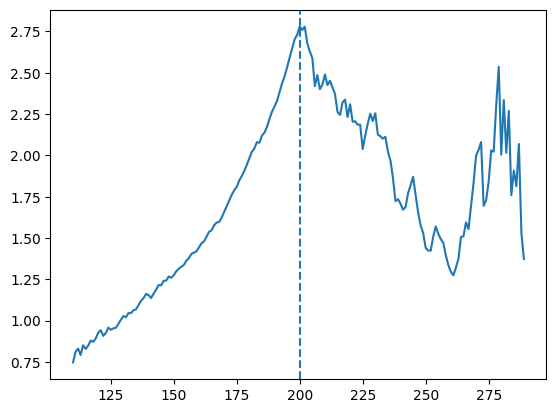

In [17]:
start = 100
end = 300

ts = np.arange(start+10, end-10)
scores = [energy_distance(x[start:t], x[t:end]) for t in ts]

plt.plot(ts, scores)
plt.axvline(200, linestyle='--')
plt.show()